# Salt Lake City AQI Predictions and Forecasting

*Basic Info:*                                                                      

Title: Salt Lake City AQI Predictions and Forecasting.                                                 

Team Members:                                                         
+ Michael Northrup, u0992000,  michael.northrup@yahoo.com
+ Grant (Rob) Olsen, u0684253, rolsenrob@gmail.com
+ Dzevad Fitozovic, u0191522, dfitozovic@hotmail.com



### Aknowledgemnets and references:

Code in this project was derived from and in some cases is identical to code from https://github.com/datascience-course and homework solutions. Ideas on how to approach a sample set which has only a few positive results, or is highly skewed was opbtained from: https://florianhartl.com/thoughts-on-machine-learning-dealing-with-skewed-classes.html. Code to do this was obtained from http://scikit-learn.org/stable/modules/cross_validation.html#cross-validation. 

## Background and Motivation.

We think that the quality of our air here in the valley is often a topic of discussion. However, the primary motivation came from one of our assignments. There we attempted to use the AQI to give us a moving average in order to be able to issue a warning to sensitive groups when an upwards trend was most likely occurring. We wanted to improve and expand on that, so in this project we want to see if we can predict the AQI for a few days in advance, creating a forecast for up to a week in advance. We also wish to see if we can make an AQI long term forecast model, so that one would be able to see how many days of poor air quality we can expect to see as our valley population rises. We do not have a background nor have we done any research in the area, but it seemed like an interesting problem. 

## Project Objectives.

Our primary objective is to devise a model to obtain an AQI forecast much like we have a weather forecast.  Additionally, we wanted to know how population growth in the valley will be affecting the number of days the AQI will reach over 101, however due to complexities with the forcast model we decided to drop this part of the project. Short term AQI data combined with weather forecasts should be useful in creating a short term forecast model. A short term model can be useful in warning sensitive groups of upcoming poor air quality days. And, if we can create a good predictive long term model, then it can be used as supporting evidence for a need to make a valley wide plan for future energy consumption that could limit the amount of pollutants like PM2.5 which accumulate due to our natural inversion conditions. 

## Deviations from Plans 

We originally planed on doing a 1-5 day AQI forecast model and a 1-5 year population growth model. However, due to the challenges with the 1-5 day model we decided to focus our energy there. Additionally, we intended to get data for weather and AQI going back to 1990. However, weather data going back that far was too unreliable, since there was a lot of missing data. We therefore fetched monthly reports from http://w2.weather.gov/climate/index.php?wfo=slc than formatted the data outside of python. Unfortunately, by this method we were only able to obtain 5 years of data going back to 11-01-2011. We believe that this should be enough for our model. Another change we needed to make is our analysis threshold. We originally planned on trying to predict if a day will be greater than or less than 101. But because so few days actually matched this criteria even a dumb model that guessed that every day will be less them 101 was over 90% accurate. We therefore changed our threshold to 51, which attempts to predict if a day will be Green or not Green.

## Data.

We will need to gather and clean a significant amount of data from several sources. For the long term
projection model the air quality data will be collected from https://www.epa.gov/outdoor-air-quality-data.
However, each year comes as a separate data-file, so it will need to be cleaned and combined.
To calculate projections for population growth we already obtained Salt Lake Valley census data from
http://www.census.gov/popest/data/index.html, and followed links to obtain historical data for years after 2010. Data formats from this source varied since the most recent years use newer data formats. Therefore, much of this data was formated and cleaned outside of the notebook. For our short term forecasting we will need an accurate 1-5 day weather forecast for the valley and previous days AQI, which we'll obtain by either web scraping http://www.weather.gov/ or more likely the API from http://openweathermap.org/. However, we may need further data sources as we continue to process the data from these sites. Some preliminary data analysis, formatting and cleanup was included in this
proposal.

In [1]:
# imports 
import pandas as pd
import requests
import json
import uuid
from IPython.display import display_javascript, display_html, display
# get needed regression and classification imports 
import numpy as np
from sklearn import tree,metrics,svm,gaussian_process,neural_network
from scipy.stats import linregress
from sklearn.linear_model import SGDRegressor, BayesianRidge,Perceptron,LogisticRegression
from sklearn.kernel_ridge import KernelRidge
#from sklearn.neural_network import MLPRegressor
import statsmodels.formula.api as sm

# from sklearn.neighbors import KNeighborsClassifier
from sklearn.cross_validation import train_test_split, cross_val_predict, cross_val_score, KFold

import matplotlib.pyplot as plt 
%pylab inline
%matplotlib inline  
plt.rcParams['figure.figsize'] = (16,12)
plt.style.use('ggplot')


C:\Anaconda3\lib\site-packages\sklearn\cross_validation.py:44: DeprecationWarning: This module was deprecated in version 0.18 in favor of the model_selection module into which all the refactored classes and functions are moved. Also note that the interface of the new CV iterators are different from that of this module. This module will be removed in 0.20.
  "This module will be removed in 0.20.", DeprecationWarning)


Populating the interactive namespace from numpy and matplotlib


## Data Processing. 

Most of the cleanup for the population data and 5 year weather data was completed in OpenOffice out of convenience. Data clean up in the long term model air quality data set is expected to be comparable to the cleanup in Homework #3. Although there is a lot more data which needed to be cleaned and combined. Unfortunately, due to changes to the scope of the project we decided to not pursue the long term forecast, so only the 5 year weather data was used in analysis. Also, we saw even more complexity in data of the data derived from the Weather API for the most recent weather forecasts. We expected that we should be able to give a fairly accurate short term AQI prediction, namely what type of air quality day one expects to have in the upcoming 5 days, and long term projections will not be pursued. 

In [2]:
# upload API data and store it in a dictionary 
response = requests.get("http://api.openweathermap.org/data/2.5/forecast?id=5780993&APPID=e0c55e00bf021f6142de334823046e9e&units=imperial")
weather = response.content.decode("utf-8")
weatherDict = json.loads(weather)

In [3]:
# print the raw dump file
print(json.dumps(weatherDict, indent=2))

{
  "cod": "200",
  "message": 0.1682,
  "list": [
    {
      "sys": {
        "pod": "n"
      },
      "clouds": {
        "all": 76
      },
      "dt": 1480755600,
      "wind": {
        "deg": 235.002,
        "speed": 4.94
      },
      "dt_txt": "2016-12-03 09:00:00",
      "weather": [
        {
          "icon": "13n",
          "id": 600,
          "description": "light snow",
          "main": "Snow"
        }
      ],
      "snow": {
        "3h": 0.055
      },
      "main": {
        "temp_max": 25.65,
        "pressure": 874.3,
        "temp_min": 25.06,
        "sea_level": 1047.48,
        "grnd_level": 874.3,
        "temp": 25.65,
        "humidity": 100,
        "temp_kf": 0.33
      }
    },
    {
      "sys": {
        "pod": "n"
      },
      "clouds": {
        "all": 56
      },
      "dt": 1480766400,
      "wind": {
        "deg": 179.505,
        "speed": 5.84
      },
      "dt_txt": "2016-12-03 12:00:00",
      "weather": [
        {
          "icon": 

In [4]:
# Method for rendering collapsible JSON from: http://stackoverflow.com/questions/18873066/pretty-json-formatting-in-ipython-notebook

class RenderJSON(object):
    def __init__(self, json_data):
        if isinstance(json_data, dict):
            self.json_str = json.dumps(json_data)
        else:
            self.json_str = json
        self.uuid = str(uuid.uuid4())

    def _ipython_display_(self):
        display_html('<div id="{}" style="height: 600px; width:100%;"></div>'.format(self.uuid),
        raw=True)
        
        display_javascript("""
        require(["https://rawgit.com/caldwell/renderjson/master/renderjson.js"], function() {
        document.getElementById('%s').appendChild(renderjson(%s))
        });
        """ % (self.uuid, self.json_str), raw=True)
        
RenderJSON(weatherDict)

In [5]:
# processing of weather forecast data. 

timeList = []
maxTempList = []
minTempList = []
pressureList = []
humidityList = []
tempList = []
wind_speedList = []
windDegList = []
precipitationList = []
rainList = []
rainListMM = []
snowList = []
snowListMM = []

for weatherEntry in weatherDict["list"]:
    timeList.append(weatherEntry["dt_txt"])
    mainWeather = weatherEntry["main"]
    maxTempList.append(mainWeather["temp_max"])
    minTempList.append(mainWeather["temp_min"])
    pressureList.append(mainWeather["pressure"])
    humidityList.append(mainWeather["humidity"])
    tempList.append(mainWeather["temp"])
    windWeather = weatherEntry["wind"]
    wind_speedList.append(windWeather["speed"])
    windDegList.append(windWeather["deg"])
    precip = 0
    if "rain" in weatherEntry:
        if "3h" in weatherEntry["rain"]:
            rainList.append(1)
            rainListMM.append(weatherEntry["rain"]["3h"])
            precip = precip + weatherEntry["rain"]["3h"]
        else:
            rainList.append(0)
            rainListMM.append(0)
    else:
        rainList.append(0)
        rainListMM.append(0)
    if "snow" in weatherEntry:
        if "3h" in weatherEntry["snow"]:
            snowList.append(1)
            snowListMM.append(weatherEntry["snow"]["3h"])
            precip = precip + weatherEntry["snow"]["3h"]
        else: 
            snowList.append(0)
            snowListMM.append(0)
    else:
        snowList.append(0)
        snowListMM.append(0)
    precipitationList.append(precip)    

In [6]:
print(precipitationList )   

[0.055, 0.0775, 0, 0, 0, 0.005, 0.0875, 0.0175, 0, 0, 0, 0, 0, 0, 0, 0.35, 1.6199999999999999, 0.23, 0.5575, 2.1224999999999996, 0.6575, 0.235, 0.1275, 0.0175, 0.0075, 0, 0.005, 0.0075, 0, 0, 0.1175, 0.7, 0.37, 0.39, 0.55, 0.08, 0.005]


In [7]:
# setup of dataframe for 5 day forecast
data = [('DateTime', timeList),
         ('MaxTemp', maxTempList),
         ('MinTemp', minTempList),
         ('Humidity', humidityList),
         ('Temperature', tempList),
         ('WindSpeed', wind_speedList), 
         ('WindDeg', windDegList),
         ('Precipitation (mm)', precipitationList)
         ]

weatherForecast = pd.DataFrame.from_items(data)
weatherForecast["DateTime"] = weatherForecast["DateTime"].apply(lambda x: str(x)[:10])

finalForecast = weatherForecast.groupby("DateTime").mean()

finalForecast["AVGtemp(F)"] = weatherForecast.groupby("DateTime").mean()["MinTemp"]
finalForecast["MINtemp(F)"] = weatherForecast.groupby("DateTime").min()["MinTemp"]
finalForecast["MAXtemp(F)"] = weatherForecast.groupby("DateTime").max()["MaxTemp"]
finalForecast["MaxWindSpeed(mph)"] = weatherForecast.groupby("DateTime").max()["WindSpeed"]
finalForecast["Avgwindspeed(mph)"] = weatherForecast.groupby("DateTime").mean()["WindSpeed"]

# Remove unused columns
del finalForecast["Humidity"]
del finalForecast["Temperature"]
del finalForecast["WindDeg"]
del finalForecast["MaxTemp"]
del finalForecast["MinTemp"]
del finalForecast["WindSpeed"]


print(finalForecast.head())

            Precipitation (mm)  AVGtemp(F)  MINtemp(F)  MAXtemp(F)  \
DateTime                                                             
2016-12-03            0.026500    25.92000       22.45       30.69   
2016-12-04            0.013750    28.27375       23.32       36.40   
2016-12-05            0.692187    33.48250       31.36       37.40   
2016-12-06            0.050000    23.66500       18.39       29.56   
2016-12-07            0.276563    18.53000       14.95       25.55   

            MaxWindSpeed(mph)  Avgwindspeed(mph)  
DateTime                                          
2016-12-03               8.39            6.36200  
2016-12-04               8.88            5.65125  
2016-12-05              16.62            8.82000  
2016-12-06               7.63            5.03875  
2016-12-07              10.11            6.85625  


In [8]:
# Load AQI data from files and group by mean for each date so that we only have 1 value for each date.
aqi_data_2011 = pd.read_csv("2011.csv",parse_dates=True)
df2011 = pd.DataFrame(aqi_data_2011).groupby("Date").mean()

aqi_data_2012 = pd.read_csv("2012.csv",parse_dates=True)
df2012 = pd.DataFrame(aqi_data_2012).groupby("Date").mean()

aqi_data_2013 = pd.read_csv("2013.csv",parse_dates=True)
df2013 = pd.DataFrame(aqi_data_2013).groupby("Date").mean()

aqi_data_2014 = pd.read_csv("2014.csv",parse_dates=True)
df2014 = pd.DataFrame(aqi_data_2014).groupby("Date").mean()

aqi_data_2015 = pd.read_csv("2015.csv",parse_dates=True)
df2015 = pd.DataFrame(aqi_data_2015).groupby("Date").mean()

aqi_data_2016 = pd.read_csv("2016.csv",parse_dates=True)
df2016 = pd.DataFrame(aqi_data_2016).groupby("Date").mean()

aqi_data_present = pd.read_csv("AQIOctNov.csv",parse_dates=True)
dfpresent = pd.DataFrame(aqi_data_present).groupby("Date").mean()

# Combine data into a single dataframe
all_aqi_data = pd.DataFrame()

all_aqi_data = df2011.append(df2012)
all_aqi_data = all_aqi_data.append(df2013)
all_aqi_data = all_aqi_data.append(df2014)
all_aqi_data = all_aqi_data.append(df2015)
all_aqi_data = all_aqi_data.append(df2016)
all_aqi_data = all_aqi_data.append(dfpresent)

# Forward fill empty values and create a column for previous day AQI 
all_aqi_data = all_aqi_data.fillna(method = 'ffill')
all_aqi_data["Previous_AQI_VALUE"] = all_aqi_data["DAILY_AQI_VALUE"].shift(1)


# Create moving average columns.
all_aqi_data["AQI 14d avg"] = np.round(all_aqi_data["DAILY_AQI_VALUE"].rolling(window = 14, center = False).mean(),2)
all_aqi_data["AQI 7d avg"] = np.round(all_aqi_data["DAILY_AQI_VALUE"].rolling(window = 7, center = False).mean(),2)
all_aqi_data["AQI 3d avg"] = np.round(all_aqi_data["DAILY_AQI_VALUE"].rolling(window = 3, center = False).mean(),2)

# Remove unused columns
del all_aqi_data["POC"]
del all_aqi_data["AQS_SITE_ID"]
del all_aqi_data["Daily Mean PM2.5 Concentration"]
del all_aqi_data["DAILY_OBS_COUNT"]
del all_aqi_data["PERCENT_COMPLETE"]
del all_aqi_data["AQS_PARAMETER_CODE"]
del all_aqi_data["CBSA_CODE"]
del all_aqi_data["STATE_CODE"]
del all_aqi_data["COUNTY_CODE"]
del all_aqi_data["SITE_LATITUDE"]
del all_aqi_data["SITE_LONGITUDE"]

# remove data prior to 11/01/2011 to match up with aquired weather data
all_aqi_data = all_aqi_data ["11/01/2011":]
all_aqi_data.head()

,DAILY_AQI_VALUE,Previous_AQI_VALUE,AQI 14d avg,AQI 7d avg,AQI 3d avg
Date,,,,,
11/01/2011,16.5,26.5,26.37,29.38,22.56
11/02/2011,18.0,16.5,25.62,28.88,20.33
11/03/2011,16.5,18.0,24.73,27.81,17.00
11/04/2011,13.0,16.5,23.56,23.38,15.83
11/05/2011,15.0,13.0,23.20,18.60,14.83


Looking at the quintiles for the Daily AQI values, it appears like most of the time the AQI is well bellow 101. Therefore, a model that looks at predicting an AQI over 101 would probably be over 90% accurate if it only guessed that the AQI will be bellow 101 every day. Obviously that would be a useless model. So, we have modified our analysis to check if the AQI will be greater than or less than 51. This gives a more reasonable number of days where the model can fail. Due to the fact that we are using a classification method an AQI rolling average for the forecast data will not be possible. Therefore, we have included these columns to get a better sense of our data, but it will not be used in our model. 

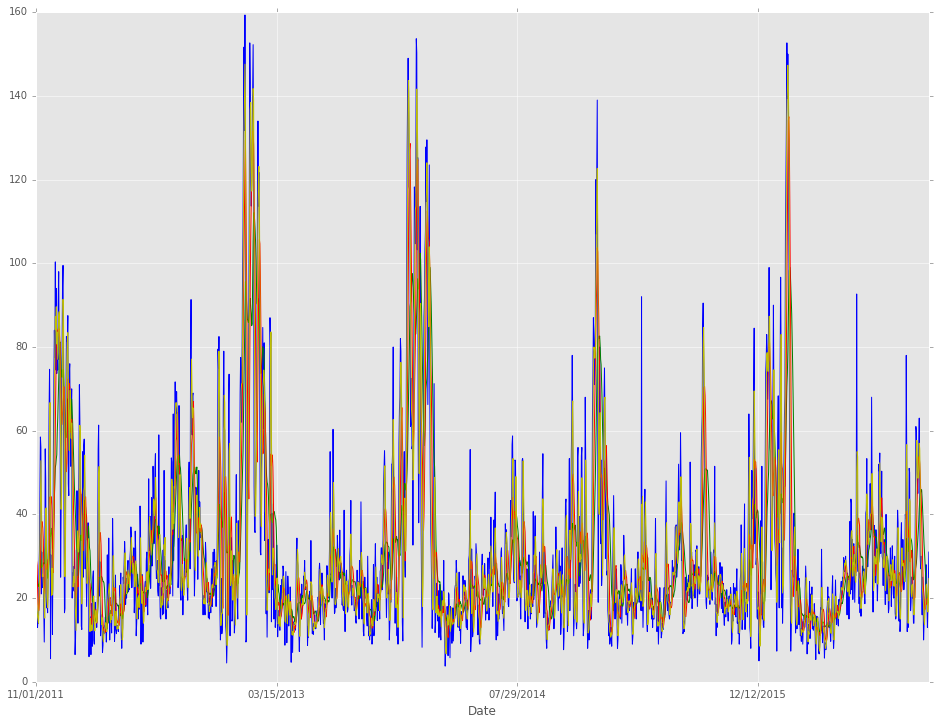

In [9]:
#visualization
all_aqi_data["DAILY_AQI_VALUE"].plot(grid = True, color = 'b');
all_aqi_data["AQI 14d avg"].plot(grid = True, color = 'g');
all_aqi_data["AQI 7d avg"].plot(grid = True, color = 'r');
all_aqi_data["AQI 3d avg"].plot(grid = True, color = 'y');

In [10]:
# Load weather data file
# This CSV file is updated manualy for the previous day's data. 
weather_data_slc = pd.read_csv("recent_climate_data.csv")
# change Percipitation and Snow units from inches to mm to fit in with 5 day forecast data 
weather_data_slc['Precipitation (mm)'] = weather_data_slc['Percipitation']*25.4
# Remove unused columns
del weather_data_slc['Percipitation']
del weather_data_slc['Snow']
# reindex by day of month. 
weather_data_slc = weather_data_slc.set_index(["Date"])
weather_data_slc.describe()

,MAXtemp(F),MINtemp(F),AVGtemp(F),Avgwindspeed(mph),MaxWindSpeed(mph),Precipitation (mm)
count,1858.000000,1858.000000,1858.000000,1858.000000,1858.000000,1858.000000
mean,66.255113,44.657158,55.701830,7.767008,19.052207,0.982234
std,21.170374,17.254137,18.983155,3.343922,7.379035,2.976061
min,14.000000,-2.000000,7.000000,1.500000,5.000000,0.000000
25%,49.250000,32.000000,41.000000,5.500000,14.000000,0.000000
50%,66.000000,44.000000,55.000000,7.100000,17.000000,0.000000
75%,85.000000,59.000000,72.000000,9.500000,24.000000,0.254000
max,105.000000,81.000000,91.000000,22.800000,51.000000,31.750000


It appears like our Precipitation and Snow data is highly skewed to the low end as indicated by the Min, 25% and 50% quantile values, which is expected in Utah. The other data columns also appear to make sense. Due to problems with merging of forecast and historical data the Snow data was removed and we kept only the percipitation data. 


## Exploratory Analysis.

We will visualize how precipitation, temperature and wind speed effect the AQI by plotting. One can definatelly see trends for percipitation and temperature. Wind's effect on the AQI is less clear. 

,MAXtemp(F),MINtemp(F),AVGtemp(F),Avgwindspeed(mph),MaxWindSpeed(mph),Precipitation (mm),DAILY_AQI_VALUE,Previous_AQI_VALUE,AQI 14d avg,AQI 7d avg,AQI 3d avg,Date,Month,Day,Year,New Date
11/01/2011,50,32,41,12.7,35,7.874,16.5,26.5,26.37,29.38,22.56,11/01/2011,11,01,2011,20111101
11/02/2011,48,27,38,4.7,13,0.000,18.0,16.5,25.62,28.88,20.33,11/02/2011,11,02,2011,20111102
11/03/2011,58,28,43,12.3,29,0.000,16.5,18.0,24.73,27.81,17.00,11/03/2011,11,03,2011,20111103
11/04/2011,64,33,49,14.1,31,6.858,13.0,16.5,23.56,23.38,15.83,11/04/2011,11,04,2011,20111104
11/05/2011,36,29,33,8.1,18,6.096,15.0,13.0,23.20,18.60,14.83,11/05/2011,11,05,2011,20111105


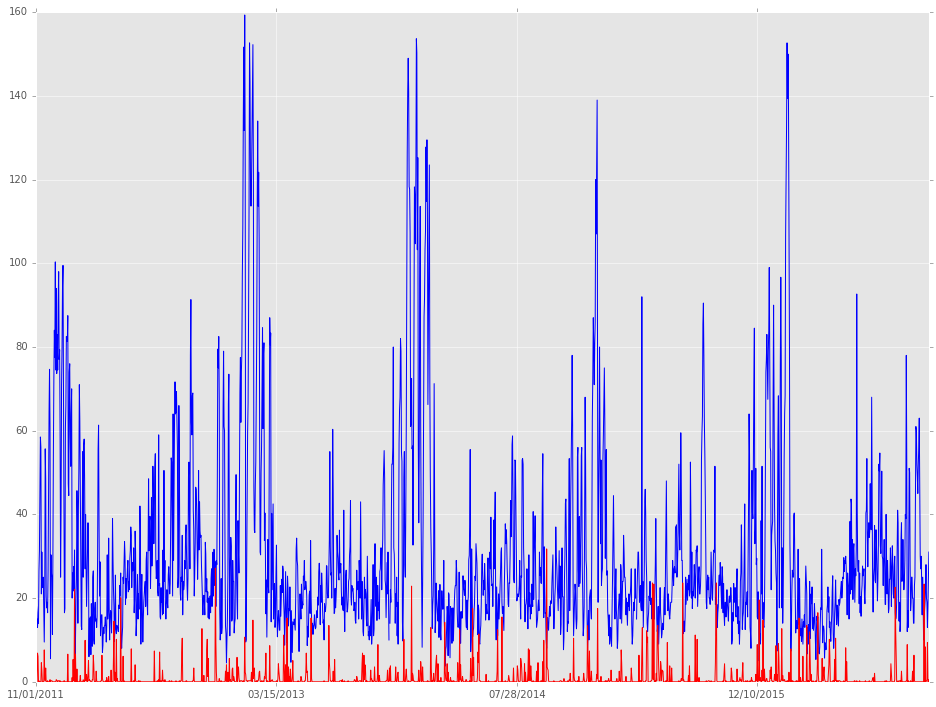

In [11]:
# add AQI data to weather data
#only appending the Daily AQI value with weather data since a rolling average will not be possible for forcast data. 
frames = [weather_data_slc, all_aqi_data] 
all_historic_data = pd.concat(frames, axis = 1)
# create column of date, month, day, and year and resort data appropriately
all_historic_data['Date'] = all_historic_data.index
all_historic_data['Month'] = all_historic_data['Date'].apply(lambda x: str(x)[:2])
all_historic_data['Day'] = all_historic_data['Date'].apply(lambda x: str(x)[3:5])
all_historic_data['Year'] = all_historic_data['Date'].apply(lambda x: str(x)[6:10])
all_historic_data['New Date'] = all_historic_data['Year']+all_historic_data['Month']+all_historic_data['Day']
all_historic_data['New Date'] = all_historic_data['New Date'].apply(int)

all_historic_data = all_historic_data.sort_values(by='New Date')
# plot of AQI and Temperature
all_historic_data['DAILY_AQI_VALUE'].plot(grid = True, color = 'b'); 
all_historic_data['Precipitation (mm)'].plot(grid = True, color = 'r');
all_historic_data.head()

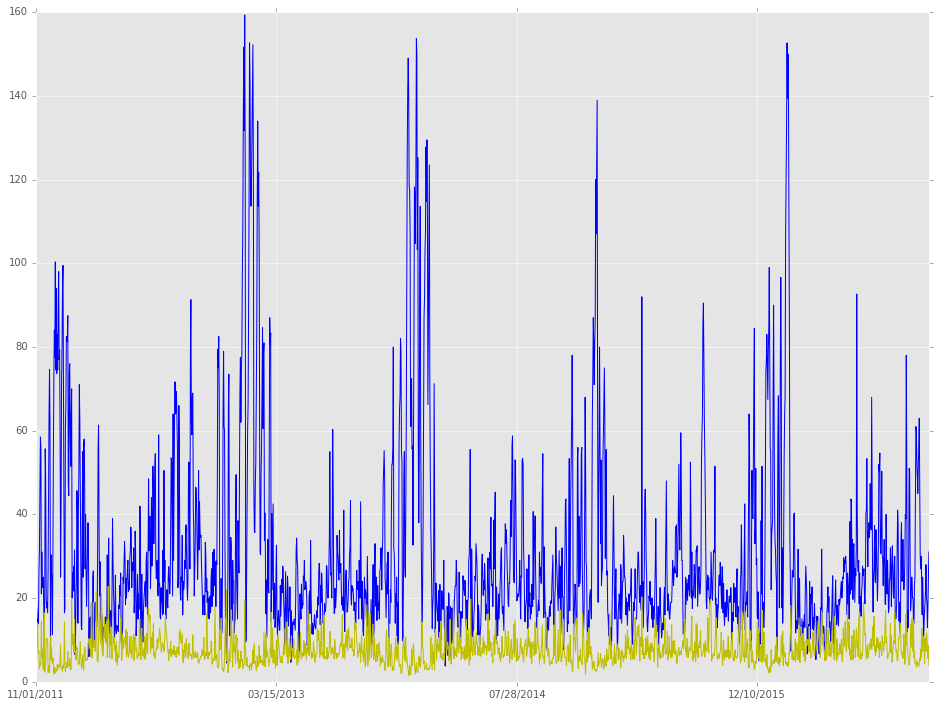

In [12]:
# plot of AQI and Avg. Wind speed
all_historic_data['DAILY_AQI_VALUE'].plot(grid = True, color = 'b'); 
all_historic_data['Avgwindspeed(mph)'].plot(grid = True, color = 'y');

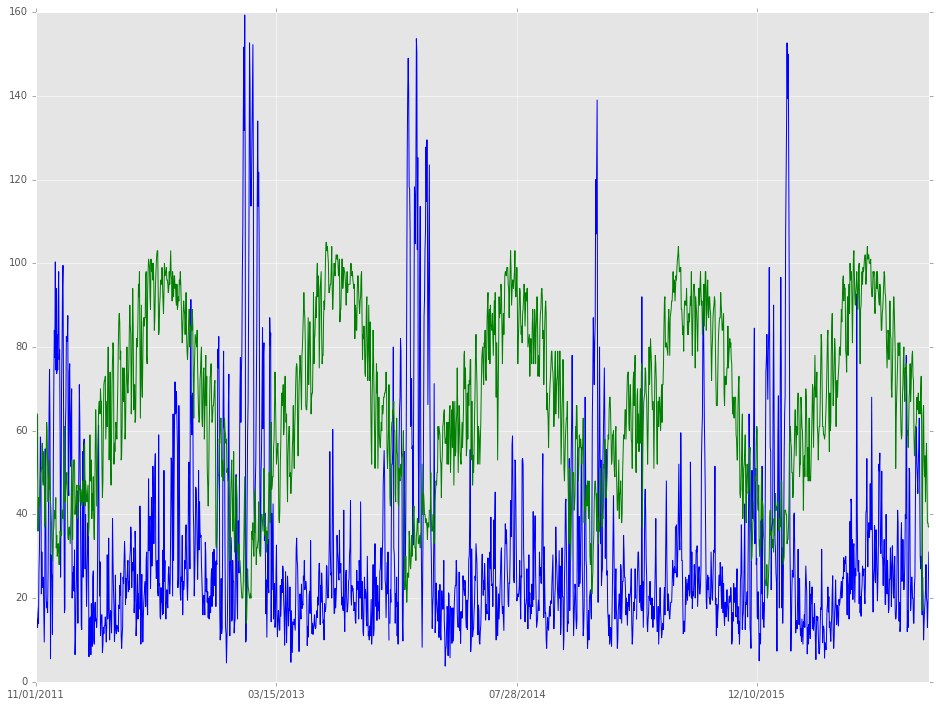

In [13]:
# plot of AQI and Max Temperature
all_historic_data['DAILY_AQI_VALUE'].plot(grid = True, color = 'b');
all_historic_data['MAXtemp(F)'].plot(grid = True, color = 'g'); 

In [14]:
#Delete unnecessary data for scatter plot matrix readablility
del all_historic_data['Day']
del all_historic_data['Year']
del all_historic_data["New Date"]

                    MAXtemp(F)  MINtemp(F)  AVGtemp(F)  Avgwindspeed(mph)  \
MAXtemp(F)            1.000000    0.952677    0.990361           0.331301   
MINtemp(F)            0.952677    1.000000    0.985404           0.364138   
AVGtemp(F)            0.990361    0.985404    1.000000           0.349720   
Avgwindspeed(mph)     0.331301    0.364138    0.349720           1.000000   
MaxWindSpeed(mph)     0.285370    0.330804    0.308964           0.812273   
Precipitation (mm)   -0.118684   -0.050125   -0.088853           0.165870   
DAILY_AQI_VALUE      -0.333054   -0.358744   -0.348717          -0.357822   
Previous_AQI_VALUE   -0.327378   -0.340760   -0.337613          -0.305508   
AQI 14d avg          -0.440558   -0.421299   -0.437117          -0.268933   
AQI 7d avg           -0.396047   -0.389447   -0.397881          -0.281400   
AQI 3d avg           -0.354870   -0.369058   -0.365762          -0.328461   

                    MaxWindSpeed(mph)  Precipitation (mm)  DAILY_AQI_VALUE 

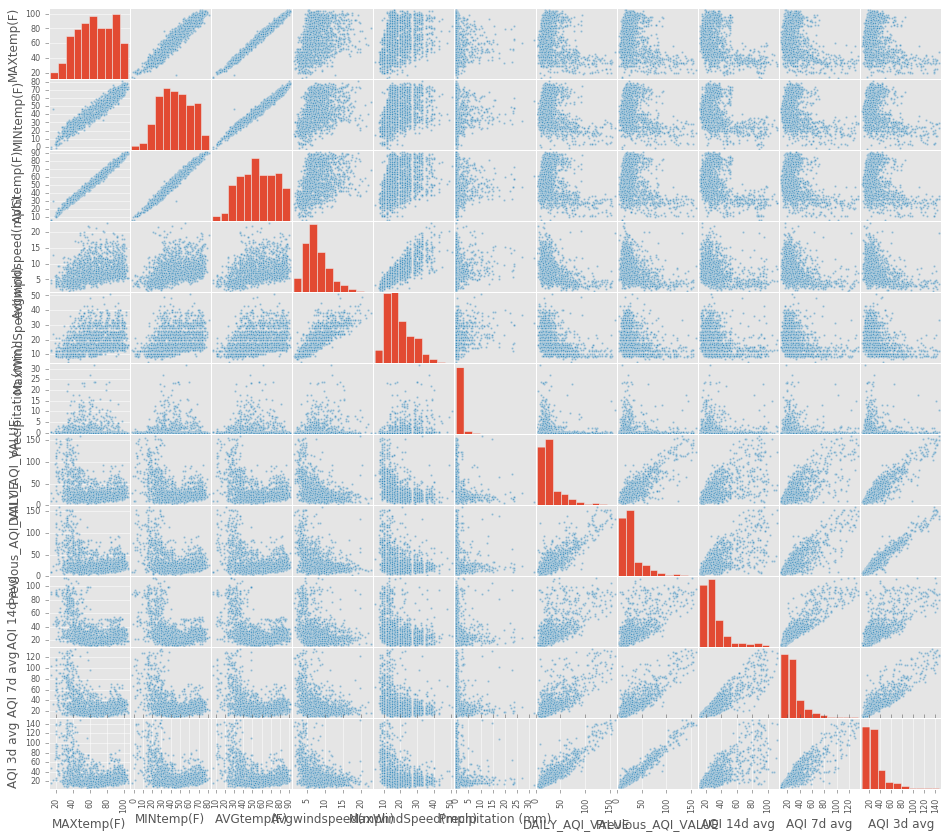

In [15]:
#Scatter plot matrix and correlation of data
print(all_historic_data.corr())
pd.scatter_matrix(all_historic_data, figsize=(16, 14), diagonal='hist');

## Analysis Methodology.

For our model, we will combine the weather predictions and past month's data to create a forecast model for up to 5 days in advance. The forecast will tell us if the next day will have an AQI greater than or less than 51. The historical data will be used to train and test the model. We will use cross validation on several different models to see which will work best. Due to the fact that our weather data comes from different sources, only select few features were usable, therefore doing further dimensionality reduction will not be needed. Models which we will use to compare are decision tree, include K-NN,and a dumb model that only uses the time of year to predict the AQI. Below is the perliminary test of the dicision tree model.  

In [16]:
#Simple model based on month of year
# set up functions for numeric classification of AQI and Month.
def AQI_to_numeric(a):
    if a >= 51:
        return 1
    else:
        return 0
def month_classifier(a):
    if a == "01":
        return 1
    else:
        return 0
# create a boolian column's for AQI greater than or less than 51 and month January or not
all_historic_data["Boolean AQI"]=all_historic_data["DAILY_AQI_VALUE"].apply(AQI_to_numeric)
all_historic_data = all_historic_data.fillna(method = 'ffill')
all_historic_data["Boolean Month"]=all_historic_data["Month"].apply(month_classifier)

In [17]:
# apply simple model to data. Simple model assumes all January days are greater than 51 and all other days to less then 51.
confusion_matrix = metrics.confusion_matrix(all_historic_data["DAILY_AQI_VALUE"].apply(AQI_to_numeric),all_historic_data["Boolean Month"])
print('Accuracy on simple model = ', str((confusion_matrix[0][0]+confusion_matrix[1][1])/confusion_matrix.sum()
))

Accuracy on simple model =  0.863832077503


In [18]:
# convert data to a matrix
y_regres = all_historic_data["DAILY_AQI_VALUE"].as_matrix()
y = all_historic_data["Boolean AQI"].as_matrix()
X = all_historic_data.drop(["DAILY_AQI_VALUE","Boolean AQI","Boolean Month","Month","Date"], axis=1).as_matrix()

In [19]:
# preliminary classification model to test accuracy on historic data. 
# cross validaton for decission tree model
depth_list = [1,2,3,4,5,10]
sample_split_list = [2,5,10,15,20,25,30,50,75,100]  
XTrain, XTest, yTrain, yTest = train_test_split(X, y,random_state=1,stratify=y, test_size=0.3)
for item1 in sample_split_list:
    print("__________________________________________________________________________________________ ")
    print ("Min. Sample Split: ", item1)
    for item2 in depth_list: 
        decisionTree = tree.DecisionTreeClassifier(max_depth=item2, min_samples_split=item1)
        decisionTree = decisionTree.fit(XTrain, yTrain)
        print("Max Depth: ", item2)
        y_pred_train = decisionTree.predict(XTrain)
        print('Accuracy on training data= ', metrics.accuracy_score(y_true = yTrain, y_pred = y_pred_train))
        y_pred = decisionTree.predict(XTest)
        print('Accuracy on test data= ', metrics.accuracy_score(y_true = yTest, y_pred = y_pred))


__________________________________________________________________________________________ 
Min. Sample Split:  2
Max Depth:  1
Accuracy on training data=  0.929230769231
Accuracy on test data=  0.937275985663
Max Depth:  2
Accuracy on training data=  0.929230769231
Accuracy on test data=  0.937275985663
Max Depth:  3
Accuracy on training data=  0.936153846154
Accuracy on test data=  0.930107526882
Max Depth:  4
Accuracy on training data=  0.946923076923
Accuracy on test data=  0.928315412186
Max Depth:  5
Accuracy on training data=  0.959230769231
Accuracy on test data=  0.939068100358
Max Depth:  10
Accuracy on training data=  0.998461538462
Accuracy on test data=  0.9229390681
__________________________________________________________________________________________ 
Min. Sample Split:  5
Max Depth:  1
Accuracy on training data=  0.929230769231
Accuracy on test data=  0.937275985663
Max Depth:  2
Accuracy on training data=  0.929230769231
Accuracy on test data=  0.937275985663
Max D

In [20]:
# Adding running averages to forcast data and filling in last know day as previous AQI
finalForecast["AQI 14d avg"] = all_historic_data["AQI 14d avg"][-1]
finalForecast["AQI 7d avg"] = all_historic_data["AQI 7d avg"][-1]
finalForecast["AQI 3d avg"] = all_historic_data["AQI 3d avg"][-1]
finalForecast["Previous_AQI_VALUE"] = all_historic_data["Previous_AQI_VALUE"][-1]

# create training sets
XTrain2, XTest2, yTrain2, yTest2 = train_test_split(X, y_regres,stratify=y, test_size=0.3)

In [21]:
# projecting forward the previous days AQI using Kernel Ridge Regression

# Kernel Ridge Regression with linear kernel
#KRR_model = KernelRidge(kernel='linear')
# train the model
#KRR_model.fit(XTrain2,yTrain2)

# iterate over each value to create the 
#y_pred3 = []
#for row in finalForecast: 
#    X_final = finalForecast[row].as_matrix()
#    finalForecast["Previous_AQI_VALUE"][row].replace(KRR_model.predict(X_final))
#print(" By KRR model: Next 5 days the AQI will be: ", finalForecast["Previous_AQI_VALUE"])

In [22]:
# preliminary attempt at forecasting AQI based on 5 day weather forecast. 
# according to cross validation we get the best results by using a max depth of 4 and a min. sample split of 10
# however, this model at ~89.5% accuracy is only marginaly better than the dumb model at ~86%,
# so we still have some work to do to improve our model.

# Create model for classification
decisionTree = tree.DecisionTreeClassifier(max_depth=3, min_samples_split=5)
decisionTree = decisionTree.fit(XTrain, yTrain)
# convert the sample set we want to predict to a matrix 
X_final = finalForecast.as_matrix()
# run decision tree model on new data
y_pred_final = decisionTree.predict(X_final)
print(" By Decision Tree model: Next 5 days the AQI will be: ", y_pred_final, " 0 = green, 1 = not green")
print(" ")
print(decisionTree.tree_.children_left) #array of left children
print(decisionTree.tree_.children_right) #array of right children
print(decisionTree.tree_.feature) #array of nodes splitting feature
print(decisionTree.tree_.threshold) #array of nodes splitting points
#print(decisionTree.tree_.value) #array of nodes values


 By Decision Tree model: Next 5 days the AQI will be:  [0 0 0 0 0]  0 = green, 1 = not green
 
[ 1  2  3 -1 -1  6 -1 -1  9 10 -1 -1 13 -1 -1]
[ 8  5  4 -1 -1  7 -1 -1 12 11 -1 -1 14 -1 -1]
[ 9  9  3 -2 -2  3 -2 -2  9  7 -2 -2  7 -2 -2]
[ 46.02999878  33.45500183   4.0999999   -2.          -2.           5.75
  -2.          -2.          59.97000122  30.90000153  -2.          -2.
  93.00500488  -2.          -2.        ]


In [23]:
# Perceptron classification model 
perceptron = Perceptron(n_iter=5000, warm_start=True) # n_iter and warm_start did not seem to effect the performance 
perceptron.fit(XTrain, yTrain)

y_pred_train = perceptron.predict(XTrain)
print('Accuracy on training data = ', metrics.accuracy_score(y_true = yTrain, y_pred = y_pred_train))
y_pred = perceptron.predict(XTest)
print('Accuracy on test data = ', metrics.accuracy_score(y_true = yTest, y_pred = y_pred))
y_pred2 = perceptron.predict(X_final)
print("By Perceptron model: Next 5 days the AQI will be: ", y_pred2)

Accuracy on training data =  0.933076923077
Accuracy on test data =  0.931899641577
By Perceptron model: Next 5 days the AQI will be:  [0 0 0 0 0]


In [24]:
#Multi-layer Perceptron regressor.
#from sklearn.neural_network import MLPRegressor
XTrain2, XTest2, yTrain2, yTest2 = train_test_split(X, y_regres,stratify=y, test_size=0.3)
neuro_model = neural_network.MLPRegressor(hidden_layer_sizes=200, activation='logistic',solver='sgd', shuffle=False,warm_start=False)
neuro_model.fit(XTrain2, yTrain2)

y_pred_train = neuro_model.predict(XTrain2)
print('R^2 training data = ', metrics.r2_score(y_true = yTrain2, y_pred = y_pred_train))
y_pred = neuro_model.predict(XTest2)
print('R^2 on test data = ', metrics.r2_score(y_true = yTest2, y_pred = y_pred))
y_pred2 = neuro_model.predict(X_final)
print("By Perceptron model: Next 5 days the AQI will be: ", y_pred2)

R^2 training data =  0.758643869365
R^2 on test data =  0.76475403161
By Perceptron model: Next 5 days the AQI will be:  [ 41.3672015   37.28757543  29.08436677  46.88187096  50.29580104]


In [25]:
# SVM regression model prediction
XTrain2, XTest2, yTrain2, yTest2 = train_test_split(X, y_regres,random_state=50,stratify=y, test_size=0.3) 
svm_model = svm.SVR(kernel='rbf', C = 50)
svm_model.fit(XTrain2,yTrain2)
y_pred_train = svm_model.predict(XTrain2)
model_acc = metrics.r2_score(y_true=yTrain2, y_pred=y_pred_train, multioutput='uniform_average')
print(" SVM training R squared score: " ,model_acc)
y_pred_test = svm_model.predict(XTest2)
model_acc2 = metrics.r2_score(y_true=yTest2, y_pred=y_pred_test, multioutput='uniform_average')

print(" SVM testing R squared score: " ,model_acc2)
# predict AQI for next 5 days
y_pred2 = svm_model.predict(X_final)
print(" By SVM model: Next 5 days the AQI will be: ", y_pred2)

 SVM training R squared score:  0.87733838186
 SVM testing R squared score:  0.0143399490969
 By SVM model: Next 5 days the AQI will be:  [ 30.45248114  30.45248114  30.45248114  30.45248114  30.45248114]


In [26]:
# BayesianRidge model
BR_model = BayesianRidge(compute_score=True)
BR_model.fit(XTrain2,yTrain2)
y_pred_train = BR_model.predict(XTrain2)
model_acc = score(y_true=yTrain2, y_pred=y_pred_train, multioutput='uniform_average')
print(" BR training R squared score: " ,model_acc)
y_pred_test = BR_model.predict(XTest2)
model_acc2 = score(y_true=yTest2, y_pred=y_pred_test, multioutput='uniform_average')
print(" BR testing R squared score: " ,model_acc2)
# predict AQI for next 5 days
y_pred2 = BR_model.predict(X_final)
print(" By Basian Ridge model: Next 5 days the AQI will be: ", y_pred2)

NameError: name 'score' is not defined

In [ ]:
# LogisticRegression obtains probabilities then classifies to binary 0,1.
LR_model = LogisticRegression(C=10,solver='liblinear')
LR_model.fit(XTrain,yTrain) 
y_pred_train = LR_model.predict(XTrain)
model_acc = metrics.accuracy_score(y_true=yTrain, y_pred=y_pred_train) 
print(" Logistic Regression training accuracy: " ,model_acc)
y_pred_test = LR_model.predict(XTest)
model_acc2 = metrics.accuracy_score(y_true=yTest, y_pred=y_pred_test)
print(" Logistic Regression testing accuracy: " ,model_acc2)
# predict AQI for next 5 days
y_pred2 = LR_model.predict(X_final)
print(" By Logistic Regression model: Next 5 days the AQI will be: ", y_pred2)

In [ ]:
# Decision tree regression cross validation 
depth_list = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,20]
sample_split_list = [2,5,10,15,20,25,30,50,75,100]  
XTrain2, XTest2, yTrain2, yTest2 = train_test_split(X, y_regres,random_state=1,stratify=y, test_size=0.3)
for item1 in sample_split_list:
    print("__________________________________________________________________________________________ ")
    print ("Min. Sample Split: ", item1)
    for item2 in depth_list: 
        decisionTree = tree.DecisionTreeRegressor(max_depth=item2, min_samples_split=item1)
        decisionTree = decisionTree.fit(XTrain2, yTrain2)
        print("Max Depth: ", item2)
        y_pred_train = decisionTree.predict(XTrain2)
        print('Accuracy on training data= ', metrics.r2_score(y_true = yTrain2, y_pred = y_pred_train))
        y_pred = decisionTree.predict(XTest2)
        print('Accuracy on test data= ', metrics.r2_score(y_true = yTest2, y_pred = y_pred))


In [ ]:
# Create model for Decision Tree Regression 
decisionTree = tree.DecisionTreeRegressor(max_depth=5, min_samples_split=5)
decisionTree = decisionTree.fit(XTrain2, yTrain2)
# convert the sample set we want to predict to a matrix 
X_final = finalForecast.as_matrix()
# predict AQI for next 5 days
y_pred2 = decisionTree.predict(X_final)
print(" By Decision Tree Regression model: Next 5 days the AQI will be: ", y_pred2)

All models predicts that the next 5 days will be green air days. 

In [ ]:
# Kernel Ridge Regression with linear kernel
KRR_model = KernelRidge(kernel='linear')
# train the model
KRR_model.fit(XTrain2,yTrain2)
# check the train model
y_pred_train = KRR_model.predict(XTrain2)
model_acc = metrics.r2_score(y_true=yTrain2, y_pred=y_pred_train)
print(" KRR training R squared score: " ,model_acc)
# test of the model on supset of historical data
y_pred_test = KRR_model.predict(XTest2)
model_acc2 = metrics.r2_score(y_true=yTest2, y_pred=y_pred_test)
print(" KRR testing R squared score: " ,model_acc2)
# predict AQI for next 5 days
y_pred2 = KRR_model.predict(X_final)
print(" By KRR model: Next 5 days the AQI will be: ", y_pred2)

In [ ]:
# Rewriting running averages more accurately using predicted values from Kernel Ridge Regression with linear kernel
# for AQI
values_to_average14d = np.zeros(13)


for i in range(1,13):
    values_to_average14d[i-1] = all_historic_data["DAILY_AQI_VALUE"][-i]

values_to_average7d = np.zeros(6)

for i in range(1,6):
    values_to_average7d[i-1] = all_historic_data["DAILY_AQI_VALUE"][-i]
    
values_to_average3d = np.zeros(2)

for i in range(1,2):
    values_to_average3d[i-1] = all_historic_data["DAILY_AQI_VALUE"][-i]

lengthFF = len(finalForecast["AQI 14d avg"])
array14d = np.zeros(lengthFF)
array7d = np.zeros(lengthFF)
array3d = np.zeros(lengthFF)
predictedvalue = y_pred2

for i in range(0,(lengthFF-1)):
    average = (sum(values_to_average14d)+predictedvalue[i])/14
    values_to_average14d[-i-1] = predictedvalue[i]
    array14d[i] = average


for i in range(0,(lengthFF-1)):
    average = (sum(values_to_average7d)+predictedvalue[i])/7
    values_to_average7d[-i-1] = predictedvalue[i]
    array7d[i] = average


for i in range(0,(lengthFF-1)):
    average = (sum(values_to_average3d)+predictedvalue[i])/3
    values_to_average3d[(i+1)%2] = predictedvalue[i]
    array3d[i] = average


finalForecast["AQI 14d avg"] = array14d
finalForecast["AQI 7d avg"] = array7d
finalForecast["AQI 3d avg"] = array3d


In [ ]:
#Code for truncating the data

#def season_classifier(a):
#    if a == "01":
#        return True
#    elif a == "02":
#        return True
#    elif a == "11":
#        return True
#    elif a == "12":
#        return True
#    else:
#        return False
#all_historic_data = all_historic_data[all_historic_data["Month"].apply(season_classifier)]


## Project Schedule. 

We plan on mostly working together to achieve each project deadline. However, some work will need to be divided out if we are unable to reach each week's objective during team meetings. 

By Friday 11-04-16
+ Obtain and format long term climate, population and AQI data. (Rob, Michael and Dzevad)
+ Obtain and format short term climate and AQI data. (Rob, Michael and Dzevad)
+ Obtain current weather forecast using an API. (Rob, Michael and Dzevad)

By Friday 11-11-16 
+ Create a long term forecasting model and test it on year 2015. (Rob, Michael and Dzevad) 
+ Create a short term forecasting model and check if it is able to predict a few days ahead. (Rob, Michael and Dzevad) 

By Friday 11-18-16
+ Tested the short term and long term model. (Rob, Michael and Dzevad)
+ Created plots to help visualize the data. (Rob, Michael and Dzevad)
+ Turn in project milestone. (Rob, Michael and Dzevad)

By Wednesday 11-23-16 
+ Refine the short term and long term model. (Rob, Michael and Dzevad)
+ Begin creating Project Screen-Cast. (Rob, Michael and Dzevad)
+ Begin creating presentation. (Rob, Michael and Dzevad)

By Friday 12-02-16
+ Completed AQI perdition and forecasting project notebook. (Rob, Michael and Dzevad)
+ Completed Project Screen-Cast and presentation. (Rob, Michael and Dzevad)

